In [16]:
import pandas as pd
from scipy.stats import boxcox, shapiro
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
data = pd.read_csv("C:/Users/Chet/Documents/practice_data.csv")


In [18]:
data

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


## 35 Boxcox_transformation

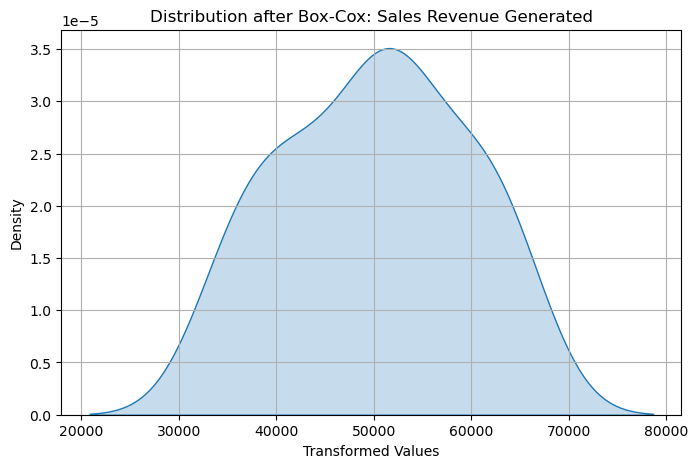

Shapiro-Wilk p-value: 0.11875345296433232


In [20]:
def boxcox_transformation(data, column_name):
    transformed_data, _ = boxcox(data[column_name])
    data[f'{column_name}_boxcox'] = transformed_data


    stat, p_value = shapiro(data[f'{column_name}_boxcox'])
    

    # KDE plot
    plt.figure(figsize=(8, 5))
    kdeplot = sns.kdeplot(data[f'{column_name}_boxcox'], fill=True)
    plt.title(f'Distribution after Box-Cox: {column_name}')
    plt.xlabel('Transformed Values')
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

    
    print('Shapiro-Wilk p-value:', p_value)

boxcox_transformation(data, 'Sales Revenue Generated')


In [21]:
data.head()

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned,Sales Revenue Generated_boxcox
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No,34964.460549
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes,64563.891859
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No,63005.976305
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No,60760.811347
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes,43127.065081


## 36 Yeojohnson_transformation

In [23]:
from scipy.stats import yeojohnson

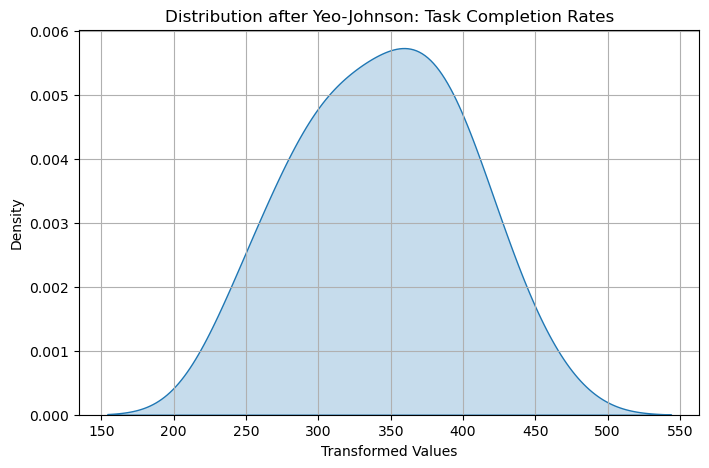

Shapiro-Wilk p-value: 0.3473


In [24]:

def yeojohnson_transformation(data, column_name):
    transformed_data, _ = yeojohnson(data[column_name])
    data[f'{column_name}_yeojohnson'] = transformed_data

    stat, p_value = shapiro(data[f'{column_name}_yeojohnson'])

    # KDE plot
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data[f'{column_name}_yeojohnson'], fill=True)
    plt.title(f'Distribution after Yeo-Johnson: {column_name}')
    plt.xlabel('Transformed Values')
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

    # Output p-value
    print(f'Shapiro-Wilk p-value: {p_value:.4f}')

yeojohnson_transformation(data, 'Task Completion Rates')


In [25]:
data.head()

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned,Sales Revenue Generated_boxcox,Task Completion Rates_yeojohnson
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No,34964.460549,391.398838
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes,64563.891859,424.141910
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No,63005.976305,359.444488
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No,60760.811347,328.306810
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes,43127.065081,391.398838


## 37  One sample

In [27]:
from scipy import stats


hypothesis_mean = 68 

t_statistic, p_value = stats.ttest_1samp(data['Sales Revenue Generated'], hypothesis_mean)

# Significance level
alpha = 0.05


print("T-statistic:", t_statistic)
print("P-value:", p_value)


T-statistic: 28.69414871437164
P-value: 2.2746688806072735e-23


In [28]:
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference between the average purchase amount and 68.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference between the average purchase amount and 68.")


Reject the null hypothesis. There is a significant difference between the average purchase amount and 68.


## 38 Independent Sample

In [33]:
churned = data.query('churned == "Yes"')['Sales Revenue Generated']
existing = data.query('churned == "No"')['Sales Revenue Generated']

t_statistic, p_value = stats.ttest_ind(churned, existing, equal_var=False) 

# Significance level
alpha = 0.05

# Print results
print("T-statistic:", t_statistic)
print("P-value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in average purchase amount between churned and existing customers.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in average purchase amount between churned and existing customers.")


T-statistic: 0.6042785459584843
P-value: 0.5504064751595374
Fail to reject the null hypothesis. There is no significant difference in average purchase amount between churned and existing customers.


## 39 One Way Anova

In [49]:
preprocessed_data = {'CustomerID': [1, 2, 3, 4, 5],
    'City': ['Los Angeles', 'New York', 'Houston', 'Los Angeles', 'New York'],
    'Frequency_of_Purchases': [7, 3, 1, 1, 12]}

preprocessed_data = pd.DataFrame(preprocessed_data)

Los_angeles = preprocessed_data.query('City == "Los Angeles"')['Frequency_of_Purchases']
New_york = preprocessed_data.query('City == "New York"')['Frequency_of_Purchases']
Houston = preprocessed_data.query('City == "Houston"')['Frequency_of_Purchases']


f_statistic, p_value = stats.f_oneway(Los_angeles, New_york, Houston)


print("F-statistic:", f_statistic)
print("P-value:", p_value)


alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in average frequency of purchases among the customers from different cities.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in average frequency of purchases among the customers from different cities.")


F-statistic: 0.517948717948718
P-value: 0.6587837837837838
Fail to reject the null hypothesis. There is no significant difference in average frequency of purchases among the customers from different cities.
